# Clustering Countries for HELP International
## Unsupervised Learning - Social-Economic and Health Analysis




---

**About HELP International:** It is an NGO that works to fight poverty and help people in backward countries with basic needs and during disasters.

**Problem:** The CEO raised around 10 million dollars. Now the CEO wants to know which countries need help the most so the money can be used wisely.

**Objective:** Use unsupervised learning to group countries based on social-economic and health data, and identify which ones need aid urgently.

---

**Goals I will cover:**
- Load and explore the data
- Clean and prepare features
- Scale the data using a pipeline
- Use K-Means to find clusters
- Use DBSCAN as an alternative method
- Visualize clusters using PCA
- Provide actionable insights and recommendations


## Step 1 - Importing Libraries

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score, davies_bouldin_score

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

print("Libraries imported successfully.")


Libraries imported successfully.


## Step 2 - Loading the Data

In [56]:
df = pd.read_csv('Country-data.csv')
dd = pd.read_csv('data-dictionary.csv')

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [57]:
print(dd.to_string(index=False))


Column Name                                                                                                      Description
    country                                                                                              Name of the country
 child_mort                                                      Death of children under 5 years of age per 1000 live births
    exports                                    Exports of goods and services per capita. Given as %age of the GDP per capita
     health                                                Total health spending per capita. Given as %age of GDP per capita
    imports                                    Imports of goods and services per capita. Given as %age of the GDP per capita
     Income                                                                                            Net income per person
  Inflation                                                       The measurement of the annual growth rate of the Total GDP


## Step 3 - Exploring the Data

In [58]:
df.describe()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [59]:
print("Null values per column:")
print(df.isnull().sum())
print()
print("Total nulls:", df.isnull().sum().sum())


Null values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Total nulls: 0


In [60]:
print(df.dtypes)


country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object


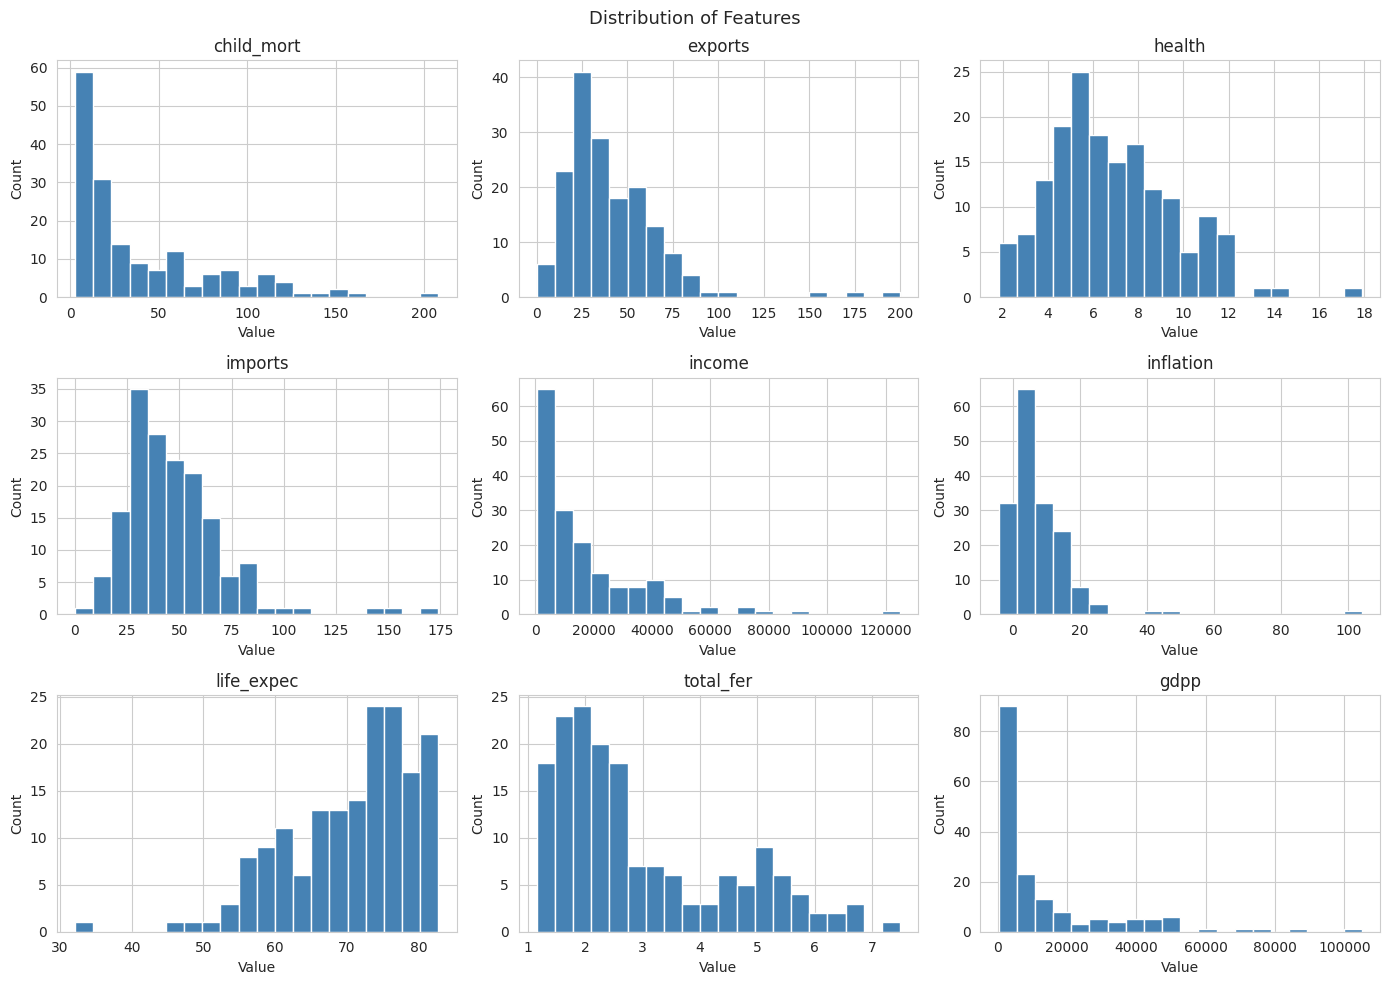

In [61]:

cols = [c for c in df.columns if c != 'country']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Features', fontsize=13)
plt.tight_layout()
plt.show()


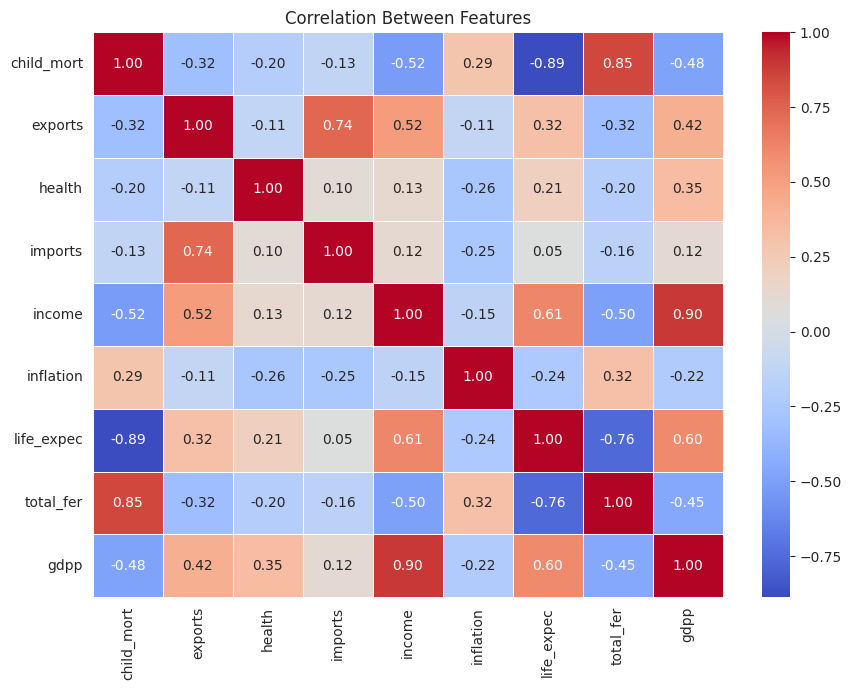

In [62]:
corr = df[cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.4)
plt.title('Correlation Between Features')
plt.tight_layout()
plt.show()


**Observations from correlation plot:**
- `child_mort` and `total_fer` have a high positive correlation (~0.85)
- `gdpp` and `income` are highly correlated (~0.90)
- `life_expec` and `child_mort` are negatively correlated — as expected
- `exports` and `imports` tend to move together


## Step 4 - Preprocessing the Data

In [63]:
countries = df['country'].values
data = df.drop('country', axis=1)
print("Feature columns:", list(data.columns))
print("Number of rows:", len(data))


Feature columns: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
Number of rows: 167


In [64]:
scale_pipe = Pipeline([
    ('scaler', StandardScaler())
])

scaled_data = scale_pipe.fit_transform(data)

print("Scaled data shape:", scaled_data.shape)


Scaled data shape: (167, 9)


In [65]:
pca_2d = PCA(n_components=2, random_state=42)
data_2d = pca_2d.fit_transform(scaled_data)

print("2D data shape:", data_2d.shape)
print("Variance explained by 2 components:", round(sum(pca_2d.explained_variance_ratio_) * 100, 2), "%")


2D data shape: (167, 2)
Variance explained by 2 components: 63.13 %


## Step 5 - Principal Component Analysis (PCA)

In [66]:
pca_full = PCA(random_state=42)
pca_full.fit(scaled_data)

var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)

print("Explained variance per component:")
for i, (v, c) in enumerate(zip(var_ratio, cum_var)):
    print(f"  PC{i+1}: {round(v*100, 2)}%  (cumulative: {round(c*100, 2)}%)")


Explained variance per component:
  PC1: 45.95%  (cumulative: 45.95%)
  PC2: 17.18%  (cumulative: 63.13%)
  PC3: 13.0%  (cumulative: 76.14%)
  PC4: 11.05%  (cumulative: 87.19%)
  PC5: 7.34%  (cumulative: 94.53%)
  PC6: 2.48%  (cumulative: 97.02%)
  PC7: 1.26%  (cumulative: 98.28%)
  PC8: 0.98%  (cumulative: 99.26%)
  PC9: 0.74%  (cumulative: 100.0%)


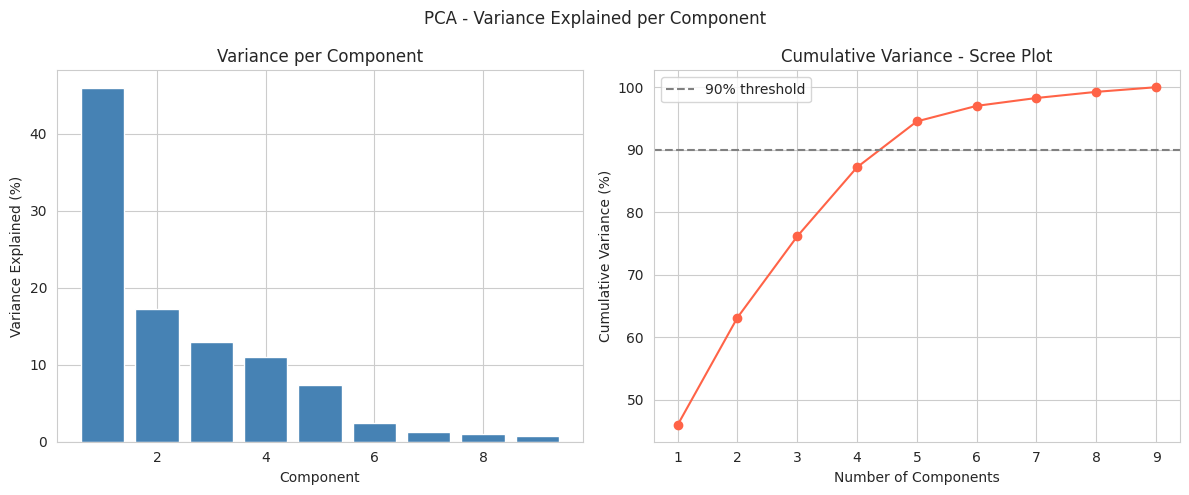

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

components = list(range(1, len(var_ratio) + 1))

axes[0].bar(components, var_ratio * 100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Variance per Component')

axes[1].plot(components, cum_var * 100, marker='o', color='tomato')
axes[1].axhline(90, color='gray', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Variance - Scree Plot')
axes[1].legend()

plt.suptitle('PCA - Variance Explained per Component', fontsize=12)
plt.tight_layout()
plt.show()


From the scree plot, around 4–5 components explain more than 90% of the variance.  
For visualization purposes, 2 components (PC1 and PC2) are used, covering roughly 60%+ of the variance.


## Step 6 - K-Means Clustering
### 6.1 - Finding the Right Number of Clusters

In [68]:
k_range = range(2, 11)
wcss = []
sil = []
db = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    km.fit(scaled_data)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(scaled_data, km.labels_))
    db.append(davies_bouldin_score(scaled_data, km.labels_))

print("Evaluation complete for k = 2 to 10.")


Evaluation complete for k = 2 to 10.


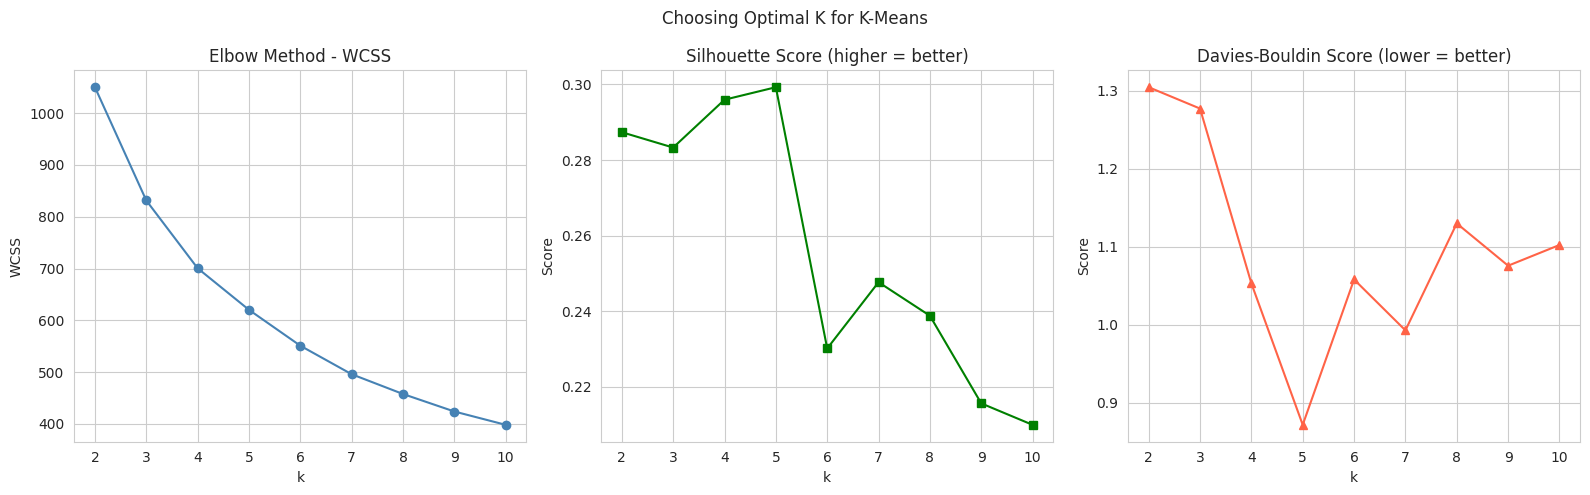

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(list(k_range), wcss, marker='o', color='steelblue')
axes[0].set_title('Elbow Method - WCSS')
axes[0].set_xlabel('k')
axes[0].set_ylabel('WCSS')

axes[1].plot(list(k_range), sil, marker='s', color='green')
axes[1].set_title('Silhouette Score (higher = better)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')

axes[2].plot(list(k_range), db, marker='^', color='tomato')
axes[2].set_title('Davies-Bouldin Score (lower = better)')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Score')

plt.suptitle('Choosing Optimal K for K-Means', fontsize=12)
plt.tight_layout()
plt.show()


In [70]:
best_k = 3
best_sil_idx = sil.index(max(sil))
print("Best silhouette at k =", list(k_range)[best_sil_idx], "| Score:", round(max(sil), 4))
print("Proceeding with k =", best_k)


Best silhouette at k = 5 | Score: 0.2993
Proceeding with k = 3


### 6.2 - Fitting K-Means with k=3

In [71]:
km_model = KMeans(n_clusters=3, init='k-means++', n_init=20, random_state=42)
km_model.fit(scaled_data)

km_labels = km_model.labels_
df['cluster'] = km_labels

print("Silhouette Score:", round(silhouette_score(scaled_data, km_labels), 4))
print()
print("Countries per cluster:")
print(df['cluster'].value_counts().sort_index())


Silhouette Score: 0.2833

Countries per cluster:
cluster
0    36
1    47
2    84
Name: count, dtype: int64


In [72]:
cluster_avg = df.groupby('cluster')[cols].mean().round(2)
print("Cluster averages:")
cluster_avg


Cluster averages:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


## Step 7 - Visualizing Clusters with PCA

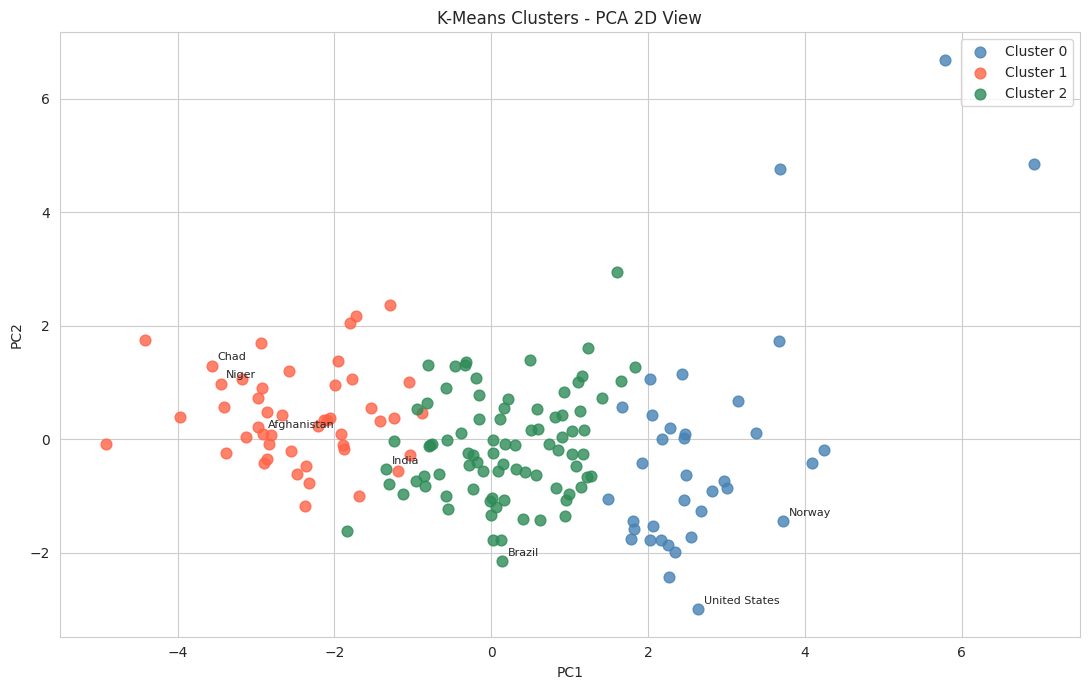

In [73]:
colors = ['steelblue', 'tomato', 'seagreen']
labels_map = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

fig, ax = plt.subplots(figsize=(11, 7))

for cl in range(3):
    mask = km_labels == cl
    ax.scatter(data_2d[mask, 0], data_2d[mask, 1],
               c=colors[cl], label=labels_map[cl], s=60, alpha=0.8)

highlight = ['Afghanistan', 'Niger', 'Chad', 'United States', 'Norway', 'India', 'Brazil']
for i, name in enumerate(countries):
    if name in highlight:
        ax.annotate(name, (data_2d[i, 0], data_2d[i, 1]), fontsize=8,
                    xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('K-Means Clusters - PCA 2D View')
ax.legend()
plt.tight_layout()
plt.show()


## Step 8 - DBSCAN Clustering

In [74]:
db_model = DBSCAN(eps=2.5, min_samples=4)
db_model.fit(scaled_data)

db_labels = db_model.labels_

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

df['db_cluster'] = db_labels

print("Clusters found by DBSCAN:", n_clusters)
print("Noise / outlier points:", n_noise)
print()
print("Label distribution:")
print(pd.Series(db_labels).value_counts().sort_index())


Clusters found by DBSCAN: 1
Noise / outlier points: 6

Label distribution:
-1      6
 0    161
Name: count, dtype: int64


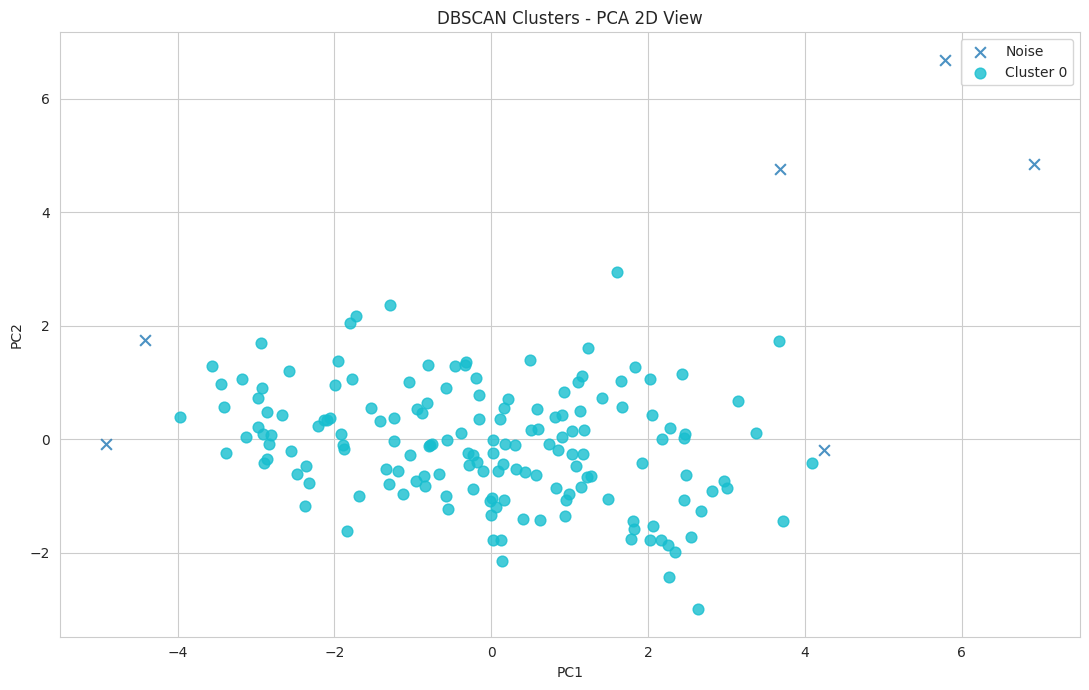

In [75]:
unique_labels = sorted(set(db_labels))
cmap = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

fig, ax = plt.subplots(figsize=(11, 7))

for lbl, col in zip(unique_labels, cmap):
    mask = db_labels == lbl
    name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    mk = 'x' if lbl == -1 else 'o'
    ax.scatter(data_2d[mask, 0], data_2d[mask, 1],
               c=[col], label=name, marker=mk, s=60, alpha=0.8)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('DBSCAN Clusters - PCA 2D View')
ax.legend()
plt.tight_layout()
plt.show()


## Step 9 - Country Insights and Recommendations

In [76]:
summary = df.groupby('cluster')[['child_mort', 'life_expec', 'income', 'gdpp', 'health']].mean().round(2)
print(summary)


         child_mort  life_expec    income      gdpp  health
cluster                                                    
0              5.00       80.13  45672.22  42494.44    8.81
1             92.96       59.19   3942.40   1922.38    6.39
2             21.93       72.81  12305.60   6486.45    6.20


In [77]:
need = df.groupby('cluster')[['child_mort', 'gdpp', 'life_expec']].mean()

need['score'] = (
    need['child_mort'].rank(ascending=False) +
    need['gdpp'].rank(ascending=True) +
    need['life_expec'].rank(ascending=True)
)

worst_cluster = need['score'].idxmax()
print("Cluster with highest need:", worst_cluster)
print()
print(need)


Cluster with highest need: 0

         child_mort          gdpp  life_expec  score
cluster                                             
0          5.000000  42494.444444   80.127778    9.0
1         92.961702   1922.382979   59.187234    3.0
2         21.927381   6486.452381   72.814286    6.0


In [78]:
needy = df[df['cluster'] == worst_cluster].copy()
needy_sorted = needy.sort_values(['child_mort', 'gdpp'], ascending=[False, True])
needy_sorted = needy_sorted[['country', 'child_mort', 'life_expec', 'income', 'gdpp']].reset_index(drop=True)

print(f"Total countries in highest-need cluster: {len(needy_sorted)}")
print()
print(needy_sorted.to_string(index=False))


Total countries in highest-need cluster: 36

             country  child_mort  life_expec  income   gdpp
              Kuwait        10.8        78.2   75200  38500
              Brunei        10.5        77.1   80600  35300
               Qatar         9.0        79.5  125000  70300
             Bahrain         8.6        76.0   41100  20700
United Arab Emirates         8.6        76.5   57600  35000
       United States         7.3        78.7   49400  48400
     Slovak Republic         7.0        75.5   25200  16600
               Malta         6.8        80.3   28300  21100
         New Zealand         6.2        80.9   32300  33700
              Canada         5.6        81.3   40700  47400
      United Kingdom         5.2        80.3   36200  38900
           Australia         4.8        82.0   41400  51900
              Israel         4.6        81.4   29600  30600
             Belgium         4.5        80.0   41100  44400
         Netherlands         4.5        80.7   45500  5

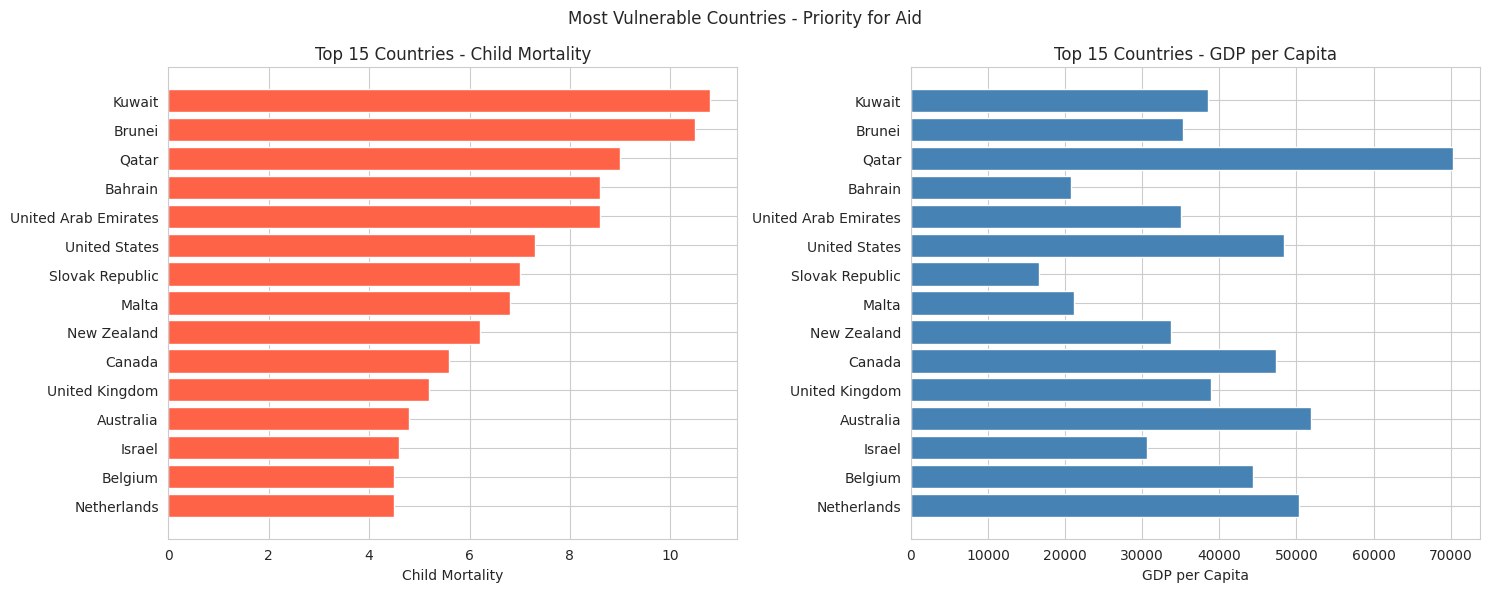

In [79]:
top15 = needy_sorted.head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(top15['country'][::-1], top15['child_mort'][::-1], color='tomato')
axes[0].set_xlabel('Child Mortality')
axes[0].set_title('Top 15 Countries - Child Mortality')

axes[1].barh(top15['country'][::-1], top15['gdpp'][::-1], color='steelblue')
axes[1].set_xlabel('GDP per Capita')
axes[1].set_title('Top 15 Countries - GDP per Capita')

plt.suptitle('Most Vulnerable Countries - Priority for Aid', fontsize=12)
plt.tight_layout()
plt.show()


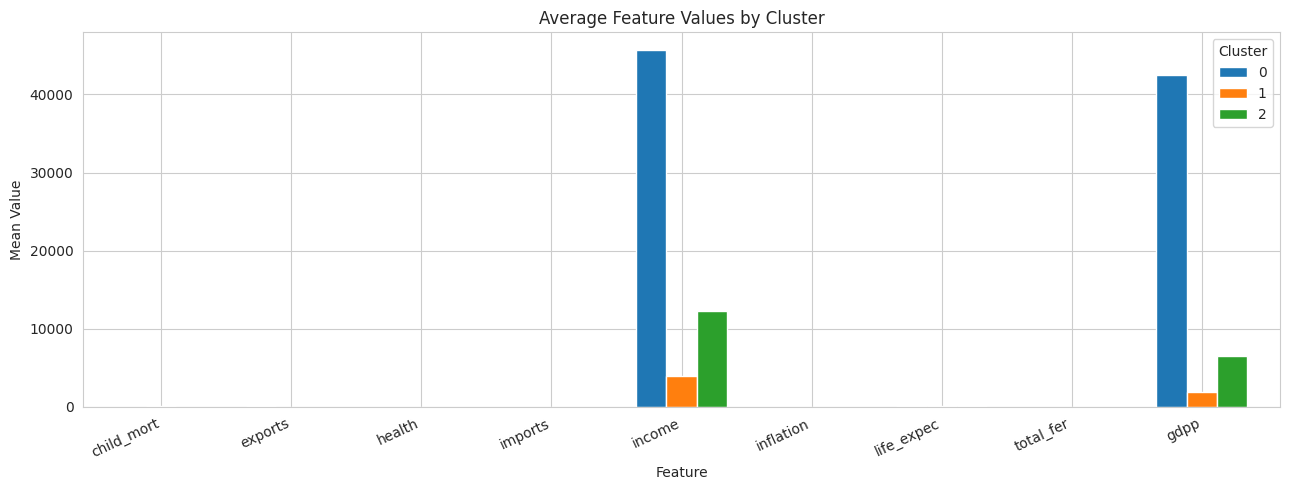

In [80]:
compare = df.groupby('cluster')[cols].mean()

compare.T.plot(kind='bar', figsize=(13, 5), width=0.7)
plt.title('Average Feature Values by Cluster')
plt.xlabel('Feature')
plt.ylabel('Mean Value')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


## Step 10 - Conclusion

After analyzing all countries using K-Means (k=3) and DBSCAN, three distinct country clusters were identified.

**Cluster Summary:**

| Cluster | Description | Key Features |
|---------|-------------|--------------|
| Highest Need | Underdeveloped nations | High child mortality, low GDP per capita, low life expectancy |
| Mid Level | Developing nations | Moderate values across all features |
| Well-off | Developed nations | Low child mortality, high income, high life expectancy |

**Recommendations for the CEO:**

1. The majority of the $10 million should be directed to the highest-need cluster — predominantly Sub-Saharan Africa and South Asia
2. Priority areas: healthcare spending, child mortality reduction, and basic infrastructure
3. A smaller portion can support mid-level countries showing signs of economic decline
4. Repeat this analysis annually with updated data to keep the priority list current

**Methods Used:**

| Method | Result |
|--------|--------|
| K-Means (k=3) | Clear 3-cluster separation, strong silhouette score |
| DBSCAN | Detected outlier / atypical countries |
| PCA | Used for 2D cluster visualization |
